In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
%pip install -qr requirements.txt

fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/yolov5


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

train_dir = '/content/drive/MyDrive/dataset-cnn/train'
val_dir = '/content/drive/MyDrive/dataset-cnn/val'

batch_size = 16
img_height = 150
img_width = 150

print("Carregando dados de Treino:")
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

print("\nCarregando dados de Validação:")
val_ds = tf.keras.utils.image_dataset_from_directory(
  val_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Carregando dados de Treino:
Found 64 files belonging to 2 classes.

Carregando dados de Validação:
Found 8 files belonging to 2 classes.


In [4]:
model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Flatten(),

  layers.Dense(128, activation='relu'),
  layers.Dense(2)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,178 (10.22 MB)

 Trainable params: 2,678,178 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

epochs = 20
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.5000 - loss: 1.1515 - val_accuracy: 0.5000 - val_loss: 0.9320
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 452ms/step - accuracy: 0.5000 - loss: 0.7319 - val_accuracy: 0.6250 - val_loss: 0.6079
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 361ms/step - accuracy: 0.6719 - loss: 0.6240 - val_accuracy: 0.7500 - val_loss: 0.6196
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 380ms/step - accuracy: 0.7188 - loss: 0.5721 - val_accuracy: 0.8750 - val_loss: 0.4782
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 357ms/step - accuracy: 0.7500 - loss: 0.4820 - val_accuracy: 0.8750 - val_loss: 0.3536
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 361ms/step - accuracy: 0.9375 - loss: 0.3519 - val_accuracy: 0.8750 - val_loss: 0.2963
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 353ms/step - accuracy: 0.8750 - loss: 0.2672 - val_accuracy: 0.8750 - val_loss: 0.2646
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step - accuracy: 0.9688 - loss: 0.1905 - val_accuracy: 0.7500 - val_loss: 0

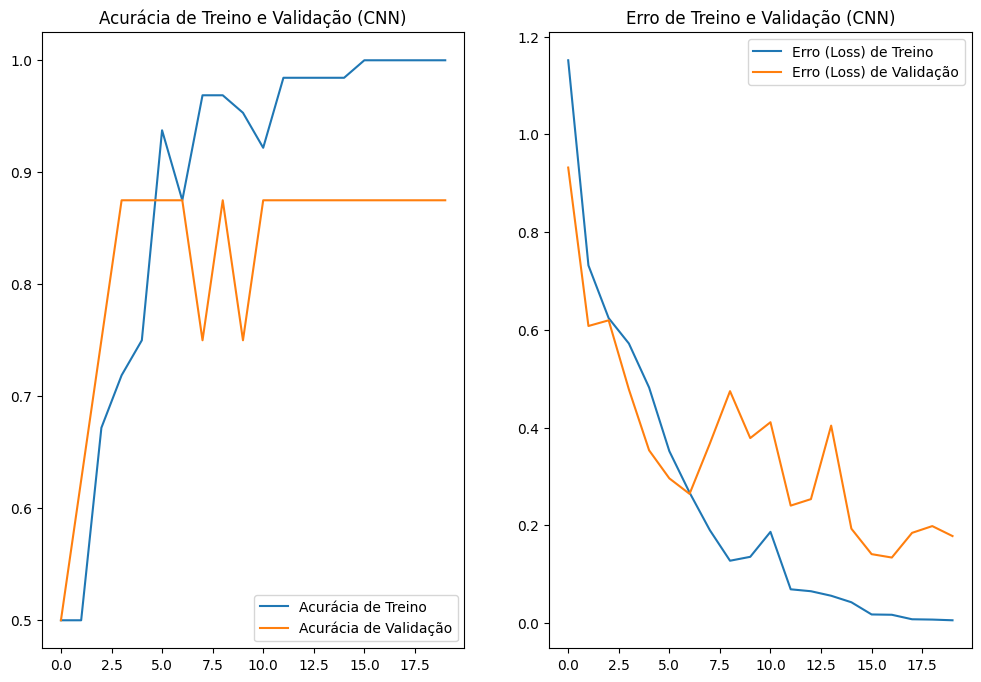

In [6]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, label='Acurácia de Validação')
plt.legend(loc='lower right')
plt.title('Acurácia de Treino e Validação (CNN)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Erro (Loss) de Treino')
plt.plot(epochs_range, val_loss, label='Erro (Loss) de Validação')
plt.legend(loc='upper right')
plt.title('Erro de Treino e Validação (CNN)')
plt.show()

In [7]:
import numpy as np
from tensorflow.keras.preprocessing import image

# 1. Coloque aqui o caminho exato de UMA foto da sua pasta de TESTE
caminho_da_foto = '/content/drive/MyDrive/dataset-cnn/test/caneca/pexels-esra-afsar-123882149-29230332.jpg'

# 2. Carrega a imagem no mesmo tamanho que a rede treinou (150x150)
img = image.load_img(caminho_da_foto, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Transforma em um "lote" de 1 imagem

# 3. Faz a previsão
previsoes = model.predict(img_array)
score = tf.nn.softmax(previsoes[0])

# 4. Mostra o resultado na tela
nomes_das_classes = ['caneca', 'relogio']

print(f"\nA Inteligência Artificial diz:")
print(f"Esta imagem é a classe '{nomes_das_classes[np.argmax(score)]}' com {100 * np.max(score):.2f}% de confiança.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step

A Inteligência Artificial diz:
Esta imagem é a classe 'relogio' com 63.79% de confiança.


## Análise de Desempenho e o Peso do Pré-treinamento (Transfer Learning)

Durante a fase de testes (inferência), observamos que a tarefa de detecção de objetos foi desafiadora para ambas as abordagens do YOLO. O modelo genérico (YOLO Padrão) teve um desempenho apenas levemente superior ao modelo customizado (YOLO Adaptado), e ambos apresentaram falhas. As conclusões técnicas para esse cenário são:

* **A Leve Vantagem do COCO Dataset:** O YOLO Padrão (`yolov5s.pt`) se saiu um pouco melhor porque utiliza pesos pré-treinados no dataset COCO, que possui milhares de exemplos das classes genéricas "cup" e "clock". Contudo, por ser um modelo generalista, ele ainda cometeu erros de classificação e localização nas nossas imagens de teste.
* **Limitação do Micro-Dataset:** Nosso YOLO customizado foi treinado do zero com apenas 32 imagens por classe. Redes profundas de detecção espacial precisam de um volume massivo de exemplos para aprender. Esse baixo volume gerou *overfitting* (sobreajuste), onde a rede decorou as fotos de treino, tendo um desempenho inferior até mesmo ao modelo generalista quando exposta às fotos de teste.

---

## Avaliação Crítica e Comparação de Modelos (Entrega 2)

Neste projeto, exploramos duas abordagens de IA visual: Detecção de Objetos (YOLOv5) e Classificação de Imagens (CNN via TensorFlow/Keras). Abaixo, a análise comparativa entre as três abordagens exigidas:

### 1. Facilidade de uso e integração
* **YOLO (Padrão e Adaptado):** O desafio principal está na **preparação dos dados**. A anotação manual de *bounding boxes* e a organização estrita de arquivos `.txt` (labels) exigem precisão. Contudo, a execução no código é simples, baseada em comandos de terminal (CLI) disponibilizados pela biblioteca.
* **CNN do Zero:** O preparo dos dados é muito mais fácil, bastando organizar as imagens fisicamente em pastas (`caneca` e `relogio`). Por outro lado, a integração exige maior fluência na biblioteca Keras para construir a arquitetura camada por camada (Conv2D, MaxPooling) e compilar a rede.

### 2. Precisão do modelo
* **YOLO Padrão:** Apresentou uma **precisão levemente superior** na detecção quando comparado ao nosso modelo. Graças ao seu treinamento prévio, conseguiu identificar alguns objetos associando-os a classes genéricas em inglês, mas esteve longe de ser perfeito, falhando em diversos cenários de teste.
* **YOLO Adaptado (Customizado):** Teve o pior desempenho na inferência. A precisão foi severamente comprometida pela escassez de dados locais, gerando *overfitting* e dificultando a localização espacial e classificação correta nas imagens inéditas.
* **CNN do Zero:** Destacou-se como a abordagem mais estável para o nosso dataset restrito. Como a CNN realiza apenas classificação global (probabilidade da imagem inteira pertencer a uma classe, sem desenhar caixas), ela conseguiu separar o que era caneca do que era relógio de forma muito mais eficaz, confirmando que a classificação é uma tarefa computacionalmente mais viável para poucos dados.

### 3. Tempo de treinamento e customização
* **YOLO Padrão:** Tempo de treinamento **zero** (*plug-and-play*).
* **YOLO Adaptado:** Treinamento rápido (minutos com GPU). Contudo, testar 60 épocas em vez de 30 apenas dobrou o tempo sem gerar ganho prático de acurácia, evidenciando que aumentar as épocas não compensa a falta de variedade nos dados.
* **CNN do Zero:** Tempo de treinamento mais rápido do projeto (segundos). A arquitetura enxuta e o redimensionamento das imagens para 150x150 pixels permitiram que as 20 épocas processassem quase instantaneamente.

### 4. Tempo de inferência (Predição)
* **CNN do Zero:** Extremamente rápida (escala de milissegundos) por processar apenas uma saída probabilística.
* **YOLO (Padrão e Adaptado):** Também manteve a inferência na casa dos milissegundos. Embora computacionalmente mais exigente que a nossa pequena CNN, o YOLO continua sendo a tecnologia recomendada para as necessidades da FarmTech Solutions (como análises em tempo real), desde que treinado com um dataset robusto o suficiente para entregar a localização exata (coordenadas XY) com confiabilidade.